In [1]:
import pandas as pd
sample_features = pd.read_csv("../data/raw/train_features_sample_50000.csv")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [3]:
y = sample_features["label"].astype(int)

X = sample_features.drop(columns=["user_id", "merchant_id", "label"])

X = X.fillna(0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(

    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

valid_prob = model.predict_proba(X_valid)[:, 1]

# 查看前 10 个用户-商家样本的复购概率
print(valid_prob[:10])

[0.50007367 0.47976981 0.42575937 0.40073342 0.53759488 0.42885952
 0.40449977 0.50857059 0.3801046  0.48151136]


In [4]:
valid_pred = (valid_prob >= 0.5).astype(int)

auc = roc_auc_score(y_valid, valid_prob)
print("AUC:", roc_auc_score(y_valid, valid_prob))

AUC: 0.6314397540456622


In [5]:
print("F1:", f1_score(y_valid, valid_pred))

F1: 0.17101353582040277


In [6]:
print("Precision:", precision_score(y_valid, valid_pred))

Precision: 0.10689228229467602


In [7]:
print("Recall:", recall_score(y_valid, valid_pred))

Recall: 0.4273927392739274


In [8]:
print("Confusion Matrix:")
print(confusion_matrix(y_valid, valid_pred))

Confusion Matrix:
[[7230 2164]
 [ 347  259]]


In [9]:
print(classification_report(y_valid, valid_pred))

              precision    recall  f1-score   support

           0       0.95      0.77      0.85      9394
           1       0.11      0.43      0.17       606

    accuracy                           0.75     10000
   macro avg       0.53      0.60      0.51     10000
weighted avg       0.90      0.75      0.81     10000



In [ ]:
#存入指标
import os

os.makedirs("../output", exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "RandomForest_Baseline",
    "sample_size": len(sample_features),
    "valid_size": len(y_valid),
    "auc": auc,
    "precision": precision_score(y_valid, valid_pred),
    "recall": recall_score(y_valid, valid_pred),
    "f1": f1_score(y_valid, valid_pred),
    "threshold": 0.5
}])

metrics_df.to_csv("../output/model_metrics_baseline.csv", index=False)

metrics_df

,model,sample_size,valid_size,auc,precision,recall,f1,threshold
0,RandomForest_Baseline,50000,10000,0.63144,0.106892,0.427393,0.171014,0.5


In [11]:
threshold_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in threshold_list:
    pred = (valid_prob >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred, zero_division=0),
        "f1": f1_score(y_valid, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.to_csv("../output/threshold_optimization_baseline.csv", index=False)

threshold_df

,threshold,precision,recall,f1
0,0.1,0.060600,1.000000,0.114275
1,0.2,0.060600,1.000000,0.114275
2,0.3,0.060649,1.000000,0.114361
3,0.4,0.068588,0.848185,0.126914
4,0.5,0.106892,0.427393,0.171014
5,0.6,0.143089,0.145215,0.144144
6,0.7,0.200000,0.031353,0.054208
7,0.8,0.200000,0.004950,0.009662
8,0.9,0.000000,0.000000,0.000000


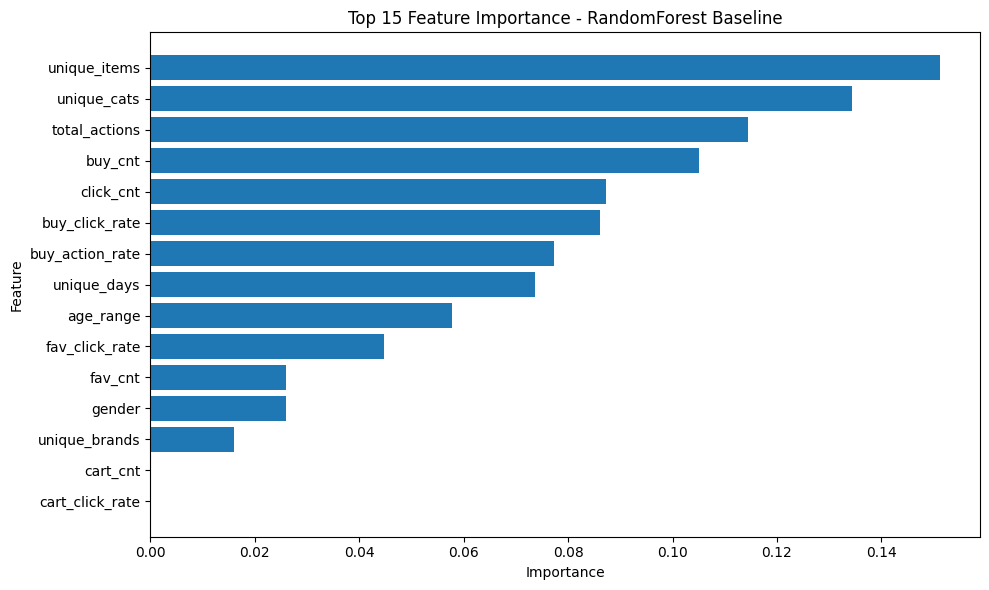

In [ ]:
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.to_csv("../output/feature_importance_baseline.csv", index=False)

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 15 Feature Importance - RandomForest Baseline")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 用户分层与增长策略

In [14]:
# 复制验证集索引对应的原始样本
# 注意：X_valid 里已经删除了 user_id 和 merchant_id
# 所以我们需要从 sample_features 中根据 X_valid 的索引取回用户和商家信息

valid_result = sample_features.loc[X_valid.index, ["user_id", "merchant_id", "label"]].copy()

# 加入模型预测出的复购概率
valid_result["repurchase_prob"] = valid_prob

# 根据复购概率划分用户层级
# 这里先用业务上容易理解的阈值：
# >= 0.7：高复购潜力
# 0.4 - 0.7：中复购潜力
# < 0.4：低复购潜力

def assign_user_segment(prob):
    if prob >= 0.7:
        return "高复购潜力用户"
    elif prob >= 0.4:
        return "中复购潜力用户"
    else:
        return "低复购潜力用户"

valid_result["user_segment"] = valid_result["repurchase_prob"].apply(assign_user_segment)

# 查看分层结果
display(valid_result.head())

# 统计每一层用户数量、真实复购率和平均预测概率
segment_summary = valid_result.groupby("user_segment").agg(
    sample_count=("user_id", "count"),
    actual_repurchase_rate=("label", "mean"),
    avg_predicted_prob=("repurchase_prob", "mean")
).reset_index()

# 按平均预测概率从高到低排序
segment_summary = segment_summary.sort_values("avg_predicted_prob", ascending=False)

display(segment_summary)

,user_id,merchant_id,label,repurchase_prob,user_segment
1140,211068,4385,0,0.500074,中复购潜力用户
40754,421298,675,0,0.479770,中复购潜力用户
17058,342946,4170,0,0.425759,中复购潜力用户
23722,394742,747,0,0.400733,中复购潜力用户
8432,4787,4850,0,0.537595,中复购潜力用户


,user_segment,sample_count,actual_repurchase_rate,avg_predicted_prob
2,高复购潜力用户,95,0.200000,0.750603
0,中复购潜力用户,7399,0.066901,0.476173
1,低复购潜力用户,2506,0.036712,0.375055


In [ ]:
# 保存用户分层明细
valid_result.to_csv("../output/user_segment_result_baseline.csv", index=False, encoding="utf-8-sig")

# 保存用户分层汇总
segment_summary.to_csv("../output/user_segment_summary_baseline.csv", index=False, encoding="utf-8-sig")